# RC3 Phase 13B: Regression Evaluation

**Objective:** Evaluate return-magnitude regressors (standalone and combined with classifiers) across 4 crypto assets and multiple bar types.

**Sections:**
1. Setup & Imports
2. Data Loading & Feature Engineering
3. Standalone Regression Evaluation (MAE, RMSE, R-squared, Implicit DA)
4. Naive Benchmark Battery (Random Walk, EWMA, Historical Mean)
5. Shuffled-Labels Sanity Check for Regressors
6. Pipeline Evaluation: Classifier + Regressor (DC-MAE, DC-RMSE, Scatter, Selection Bias, PDR)
7. Uncertainty Evaluation (Calibration, CRPS, Conformal Intervals, Sharpness)
8. Summary & Decisions

**Key Design:**
- Regression target: `fwd_logret_h` (forward log return at horizon h)
- Direction target: `fwd_dir_h` (+1 / -1)
- Two-track system: Classification -> direction (SIDE), Regression -> magnitude (SIZE)
- CPCV with purging and embargo for all train/test splits
- Honest evaluation: negative results are valid and documented

---
## 1. Setup & Imports

In [2]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# Project root resolution (works whether cwd is research/RC3 or project root)
_cwd = Path.cwd()
if _cwd.name == "RC3":
    _PROJECT_ROOT = _cwd.parent.parent
elif _cwd.name == "research":
    _PROJECT_ROOT = _cwd.parent
else:
    _PROJECT_ROOT = _cwd
os.chdir(_PROJECT_ROOT)
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import binomtest, norm
from sklearn.preprocessing import StandardScaler

# Project imports -- data loading
from src.app.system.database.connection import ConnectionManager
from src.app.research.application.data_loader import DataLoader
from src.app.features.application.feature_matrix import FeatureMatrixBuilder
from src.app.features.domain.value_objects import FeatureConfig
from src.app.research.application.cpcv_splitter import CPCVConfig, CPCVSplitter

# Project imports -- regressors
from src.app.forecasting.domain.value_objects import (
    ForecastHorizon,
    RidgeConfig,
    GradientBoostingConfig,
    GRUConfig,
    ACIConfig,
)
from src.app.forecasting.application.ridge_baseline import RidgeBaseline
from src.app.forecasting.application.gradient_boosting_reg import GradientBoostingRegressor
from src.app.forecasting.application.gru_regressor import GRURegressor

# Project imports -- classifiers (for pipeline evaluation)
from src.app.forecasting.domain.value_objects import (
    LogisticConfig,
    GradientBoostingClassifierConfig,
)
from src.app.forecasting.application.logistic_baseline import LogisticBaseline
from src.app.forecasting.application.gradient_boosting_clf import GradientBoostingClassifier

# Project imports -- metrics
from src.app.forecasting.application.regression_metrics import (
    compute_regression_metrics,
    compute_crps_gaussian,
    compute_dc_mae,
    compute_dc_rmse,
    compute_pdr,
    compute_economic_sharpe,
    RegressionMetrics,
)

# Project imports -- calibration
from src.app.forecasting.application.calibration import (
    AdaptiveConformalPredictor,
    compute_reliability_diagram,
    compute_residual_diagnostics,
    compute_regime_coverage,
)

# Plot settings
%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# Output directory
FIG_DIR = Path("research/RC3/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Global Constants (all parameters in one place -- no magic numbers)
# =============================================================================
ASSETS = ["BTCUSDT", "ETHUSDT", "LTCUSDT", "SOLUSDT"]
TARGET_BAR_TYPES = ["dollar", "volume", "vol_imbalance", "dollar_imbalance"]
HORIZONS = [ForecastHorizon.H1, ForecastHorizon.H4, ForecastHorizon.H24]
HORIZON_TO_TARGET = {
    ForecastHorizon.H1: "fwd_logret_1",
    ForecastHorizon.H4: "fwd_logret_4",
    ForecastHorizon.H24: "fwd_logret_24",
}
HORIZON_TO_DIR_TARGET = {
    ForecastHorizon.H1: "fwd_dir_1",
    ForecastHorizon.H4: "fwd_dir_4",
    ForecastHorizon.H24: "fwd_dir_24",
}

ROUND_TRIP_COST = 0.002  # 20 bps round-trip
SIGNIFICANCE_ALPHA = 0.05
MIN_BARS_THRESHOLD = 100
RANDOM_SEED = 42
CPCV_N_GROUPS = 6
CPCV_K_TEST = 2
CPCV_PURGE = 1
CPCV_EMBARGO = 5

# Stationarity transforms (Phase 7.3 policy ST1-ST4)
DROP_FEATURES = {"atr_14", "rsi_14"}
ROLLING_ZSCORE_FEATURES = ["amihud_24", "gk_vol_24"]
FIRST_DIFF_FEATURES = ["bbwidth_20_2.0", "park_vol_24", "rv_12", "rv_24", "rv_48"]
ROLLING_ZSCORE_WINDOW = 24

# Color palette for regressors
COLORS = {
    "Ridge": "#3498db",
    "Huber": "#2980b9",
    "LightGBM_Q": "#e74c3c",
    "GRU_MC": "#9b59b6",
    "RandomWalk": "#95a5a6",
    "EWMA": "#f39c12",
    "HistMean": "#1abc9c",
    "breakeven": "#e67e22",
}

# Initialize database
db_connection = ConnectionManager()
db_connection.initialize()
loader = DataLoader(db_connection)

print(f"Project root: {_PROJECT_ROOT}")
print(f"Assets: {ASSETS}")
print(f"Bar types: {TARGET_BAR_TYPES}")
print(f"Horizons: {[h.value for h in HORIZONS]}")
print("Setup complete.")

2026-04-12 18:11:59.306 | INFO     | src.app.system.database.connection:initialize:77 - Creating DuckDB engine (path=/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/data/market.duckdb)
2026-04-12 18:11:59.324 | INFO     | src.app.system.database.connection:initialize:86 - DuckDB connection verified successfully


Project root: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis
Assets: ['BTCUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT']
Bar types: ['dollar', 'volume', 'vol_imbalance', 'dollar_imbalance']
Horizons: ['h1', 'h4', 'h24']
Setup complete.


---
## 2. Data Loading & Feature Engineering

Load bar data from DuckDB, compute features and targets using the feature matrix builder,
and apply stationarity transforms (Phase 7.3 policy). Same pipeline as the classification notebook
to ensure consistency.

In [3]:
from __future__ import annotations


def prepare_features_and_targets(
    feature_set,
    horizon,
):
    """Apply stationarity transforms, build X/y arrays for regression and classification.

    Returns None if the resulting dataset has fewer than MIN_BARS_THRESHOLD rows.
    """
    df = feature_set.df.to_pandas()
    target_col = HORIZON_TO_TARGET[horizon]
    dir_col = HORIZON_TO_DIR_TARGET[horizon]

    if target_col not in df.columns:
        return None

    # Filter feature columns (drop problematic ones per Phase 7.2)
    feature_cols = [c for c in feature_set.feature_columns if c not in DROP_FEATURES]

    # Rolling z-score transforms (Phase 7.3 policy ST3)
    for col in ROLLING_ZSCORE_FEATURES:
        if col in df.columns:
            rolling_mean = df[col].rolling(ROLLING_ZSCORE_WINDOW, min_periods=ROLLING_ZSCORE_WINDOW).mean()
            rolling_std = df[col].rolling(ROLLING_ZSCORE_WINDOW, min_periods=ROLLING_ZSCORE_WINDOW).std()
            df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-12)

    # First difference transforms (Phase 7.3 policy ST2)
    for col in FIRST_DIFF_FEATURES:
        if col in df.columns:
            df[col] = df[col].diff()

    # Direction target: +1 / -1 convention
    if dir_col in df.columns:
        df["y_dir"] = df[dir_col].astype(float)
    else:
        df["y_dir"] = np.where(df[target_col] > 0, 1.0, -1.0)

    # Regression target (raw forward log return)
    df["y_reg"] = df[target_col].astype(float)

    # Drop NaN rows across features + targets
    required_cols = feature_cols + ["y_dir", "y_reg"]
    existing_required = [c for c in required_cols if c in df.columns]
    df = df.dropna(subset=existing_required).reset_index(drop=True)

    if len(df) < MIN_BARS_THRESHOLD:
        return None

    X = df[feature_cols].values.astype(np.float64)
    y_dir = df["y_dir"].values.astype(np.float64)
    y_reg = df["y_reg"].values.astype(np.float64)

    # Replace any remaining inf with 0
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    assert not np.any(np.isnan(X)), "NaN in features after transforms!"
    assert not np.any(np.isinf(X)), "Inf in features after transforms!"

    return X, y_dir, y_reg, feature_cols, df


# =============================================================================
# Load all (asset, bar_type) data and build feature matrices
# =============================================================================
builder = FeatureMatrixBuilder()
config = FeatureConfig(compute_targets=True, drop_na=True)

# Store: data_store[(asset, bar_type)] = (feature_set, bars_pd)
data_store = {}
bar_config_map = {}

for asset in ASSETS:
    bar_configs = loader.get_available_bar_configs(asset)
    bar_config_map[asset] = bar_configs
    print(f"\n{asset}: {len(bar_configs)} bar configs available")

    for bar_type, config_hash in bar_configs:
        if bar_type not in TARGET_BAR_TYPES:
            continue

        bars_pd = loader.load_bars(asset, bar_type, config_hash)
        n_raw = len(bars_pd)

        if n_raw < MIN_BARS_THRESHOLD:
            print(f"  {bar_type}: SKIP ({n_raw} bars < {MIN_BARS_THRESHOLD})")
            continue

        # Build feature matrix
        bars_pl = pl.from_pandas(bars_pd).rename({"start_ts": "timestamp"})
        feature_set = builder.build(bars_pl, config)

        if feature_set.n_rows_clean < MIN_BARS_THRESHOLD:
            print(f"  {bar_type}: SKIP ({feature_set.n_rows_clean} clean bars < {MIN_BARS_THRESHOLD})")
            continue

        data_store[(asset, bar_type)] = (feature_set, bars_pd)
        print(
            f"  {bar_type}: {n_raw} raw -> {feature_set.n_rows_clean} clean bars, "
            f"{len(feature_set.feature_columns)} features, "
            f"{len(feature_set.target_columns)} targets"
        )

print(f"\n{'=' * 60}")
print(f"Total (asset, bar_type) cells loaded: {len(data_store)}")
print(f"Cells: {list(data_store.keys())}")


BTCUSDT: 9 bar configs available
  dollar: 5287 raw -> 5164 clean bars, 23 features, 11 targets
  dollar_imbalance: 569 raw -> 446 clean bars, 23 features, 11 targets
  volume: 3264 raw -> 3141 clean bars, 23 features, 11 targets

ETHUSDT: 9 bar configs available
  dollar: 2759 raw -> 2636 clean bars, 23 features, 11 targets
  dollar_imbalance: 428 raw -> 305 clean bars, 23 features, 11 targets
  volume: 24038 raw -> 23915 clean bars, 23 features, 11 targets

LTCUSDT: 9 bar configs available
  dollar: SKIP (76 clean bars < 100)
  dollar_imbalance: SKIP (14 bars < 100)
  volume: 26987 raw -> 26864 clean bars, 23 features, 11 targets

SOLUSDT: 9 bar configs available
  dollar: 809 raw -> 686 clean bars, 23 features, 11 targets
  dollar_imbalance: SKIP (30 clean bars < 100)
  volume: 47178 raw -> 47055 clean bars, 23 features, 11 targets

Total (asset, bar_type) cells loaded: 9
Cells: [('BTCUSDT', 'dollar'), ('BTCUSDT', 'dollar_imbalance'), ('BTCUSDT', 'volume'), ('ETHUSDT', 'dollar'), (

---
## 3. Standalone Regression Evaluation

For each (asset, bar_type, horizon) triplet, train and evaluate three regressors:
1. **Ridge** -- L2-regularised linear regression (interpretable baseline)
2. **LightGBM Quantile** -- gradient boosted quantile regressor (non-linear, distributional)
3. **GRU with MC Dropout** -- recurrent neural network with epistemic uncertainty

Metrics: MAE, RMSE, R-squared, **Implicit DA** (directional accuracy of sign(predicted) vs sign(actual)).

The implicit DA is the critical metric here: if a regressor achieves DA > 50% (above coin-flip),
it implicitly captures directional signal and may make a separate classifier redundant.

In [7]:
from __future__ import annotations
import traceback

# =============================================================================
# Regressor factory and evaluation helpers
# =============================================================================


def make_regressors():
    """Create fresh regressor instances with Pydantic configs."""
    return {
        "Ridge": RidgeBaseline(RidgeConfig(alpha=1.0, use_huber=False)),
        "Huber": RidgeBaseline(RidgeConfig(alpha=1.0, use_huber=True, huber_epsilon=1.35)),
        "LightGBM_Q": GradientBoostingRegressor(
            GradientBoostingConfig(
                quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_samples=20,
            )
        ),
        "GRU_MC": GRURegressor(
            GRUConfig(
                hidden_size=32,
                num_layers=2,
                dropout=0.2,
                sequence_length=20,
                n_epochs=50,
                batch_size=32,
                mc_samples=30,
                patience=8,
            )
        ),
    }


def evaluate_regressor_on_folds(model_name, X, y_reg, folds, scaler_per_fold=True):
    """Train and evaluate a regressor across CPCV folds.

    Returns: (all_actuals, all_predictions, all_stds, per_fold_metrics)
    """
    all_actuals = []
    all_preds = []
    all_stds = []
    fold_metrics = []

    for fold_idx, fold in enumerate(folds):
        train_idx = fold.train_indices
        test_idx = fold.test_indices
        try:
            regressors = make_regressors()
            model = regressors[model_name]

            X_train, X_test = X[list(train_idx)], X[list(test_idx)]
            y_train, y_test = y_reg[list(train_idx)], y_reg[list(test_idx)]

            # Standardize features per fold (no leakage)
            if scaler_per_fold:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            preds_arr = pred.mean.astype(np.float64)
            stds_arr = pred.std.astype(np.float64)

            # GRU produces fewer predictions due to sequence_length
            n_pred = len(preds_arr)
            y_test_aligned = y_test[-n_pred:] if n_pred < len(y_test) else y_test

            metrics = compute_regression_metrics(y_test_aligned, preds_arr)
            fold_metrics.append(metrics)
            all_actuals.append(y_test_aligned)
            all_preds.append(preds_arr)
            all_stds.append(stds_arr)

        except Exception as e:
            print(f"    Fold {fold_idx}: {model_name} FAILED: {e}")
            continue

    if not all_actuals:
        return None

    return (
        np.concatenate(all_actuals),
        np.concatenate(all_preds),
        np.concatenate(all_stds),
        fold_metrics,
    )


# =============================================================================
# Run standalone evaluation across all cells
# =============================================================================
REGRESSOR_NAMES = ["Ridge", "Huber", "LightGBM_Q", "GRU_MC"]

# Results: standalone_results[(asset, bar_type, horizon, model)] = {metrics, actuals, preds, stds}
standalone_results = {}
cpcv_config = CPCVConfig(n_groups=CPCV_N_GROUPS, k_test=CPCV_K_TEST, purge_bars=CPCV_PURGE, embargo_bars=CPCV_EMBARGO)
splitter = CPCVSplitter(cpcv_config)

# Focus on dollar bars + H1 horizon first (primary combo from RC1),
# then extend to all combinations
PRIMARY_HORIZON = ForecastHorizon.H1

for (asset, bar_type), (feature_set, bars_pd) in data_store.items():
    for horizon in [PRIMARY_HORIZON]:
        result = prepare_features_and_targets(feature_set, horizon)
        if result is None:
            continue

        X, y_dir, y_reg, feature_cols, df = result
        n_samples = len(X)

        # Generate CPCV folds
        timestamps = np.arange(n_samples, dtype=np.int64)
        folds = folds = splitter.split(n_samples)

        print(f"\n{asset} / {bar_type} / {horizon.value}: {n_samples} samples, {len(folds)} folds")

        for model_name in REGRESSOR_NAMES:
            eval_result = evaluate_regressor_on_folds(model_name, X, y_reg, folds)

            if eval_result is None:
                print(f"  {model_name}: ALL FOLDS FAILED")
                continue

            actuals, preds, stds, fold_metrics = eval_result

            # Aggregate metrics across folds
            avg_mae = np.mean([m.mae for m in fold_metrics])
            avg_rmse = np.mean([m.rmse for m in fold_metrics])
            avg_r2 = np.mean([m.r_squared for m in fold_metrics])
            avg_da = np.mean([m.implicit_da for m in fold_metrics])

            standalone_results[(asset, bar_type, horizon.value, model_name)] = {
                "actuals": actuals,
                "preds": preds,
                "stds": stds,
                "fold_metrics": fold_metrics,
                "avg_mae": avg_mae,
                "avg_rmse": avg_rmse,
                "avg_r2": avg_r2,
                "avg_da": avg_da,
                "n_folds": len(fold_metrics),
                "n_samples": len(actuals),
            }

            print(
                f"  {model_name:12s}: MAE={avg_mae:.6f}  RMSE={avg_rmse:.6f}  "
                f"R2={avg_r2:.4f}  DA={avg_da:.4f}  ({len(fold_metrics)} folds)"
            )

print(f"\nTotal standalone results: {len(standalone_results)}")

2026-04-12 18:23:50.434 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5
2026-04-12 18:23:50.440 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3421 samples | residual_std=0.015068
2026-04-12 18:23:50.441 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.018616, RMSE=0.023821, R²=0.0008, DA=0.5012


2026-04-12 18:23:50.444 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.017897
2026-04-12 18:23:50.444 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.013983, RMSE=0.019482, R²=-0.0035, DA=0.5035
2026-04-12 18:23:50.447 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.017602
2026-04-12 18:23:50.448 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.014562, RMSE=0.019977, R²=-0.0057, DA=0.5053
2026-04-12 18:23:50.451 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.016824
2026-04-12 18:23:50.452 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.0164


BTCUSDT / dollar / h1: 5141 samples, 15 folds
  Ridge       : MAE=0.013685  RMSE=0.018286  R2=-0.0051  DA=0.5052  (15 folds)


2026-04-12 18:23:50.685 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 3421 samples | residual_std=0.015076
2026-04-12 18:23:50.686 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.018600, RMSE=0.023805, R²=0.0021, DA=0.5076
2026-04-12 18:23:50.779 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 3414 samples | residual_std=0.017910
2026-04-12 18:23:50.780 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.013962, RMSE=0.019471, R²=-0.0023, DA=0.4936
2026-04-12 18:23:50.860 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 3414 samples | residual_std=0.017618
2026-04-12 18:23:50.861 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression me

  Huber       : MAE=0.013667  RMSE=0.018278  R2=-0.0043  DA=0.5038  (15 folds)


...

  Huber       : MAE=0.008229  RMSE=0.011523  R2=-0.0022  DA=0.5152  (15 folds)


2026-04-12 18:32:22.576 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31348 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:32:22.744 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=15678): MAE=0.011584, RMSE=0.015446, R²=-0.0146, DA=0.5135
2026-04-12 18:32:23.969 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31341 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:32:24.126 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=15678): MAE=0.010071, RMSE=0.014110, R²=-0.0106, DA=0.5055
2026-04-12 18:32:25.356 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31341 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:32:25.520

  LightGBM_Q  : MAE=0.008268  RMSE=0.011585  R2=-0.0131  DA=0.5121  (15 folds)


2026-04-12 18:32:57.503 | INFO     | src.app.forecasting.application.gru_regressor:_run_training_loop:302 - Early stopping at epoch 16 | train_loss=0.000095 val_loss=0.000067
2026-04-12 18:32:57.503 | INFO     | src.app.forecasting.application.gru_regressor:fit:140 - GRU fitted: 16 epochs | best_val_loss=0.000064 | seq_len=20 | train_seqs=25063 val_seqs=6265
2026-04-12 18:32:57.658 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=15658): MAE=0.011540, RMSE=0.015325, R²=-0.0008, DA=0.5106
2026-04-12 18:33:07.303 | INFO     | src.app.forecasting.application.gru_regressor:_run_training_loop:302 - Early stopping at epoch 10 | train_loss=0.000120 val_loss=0.000066
2026-04-12 18:33:07.304 | INFO     | src.app.forecasting.application.gru_regressor:fit:140 - GRU fitted: 10 epochs | best_val_loss=0.000064 | seq_len=20 | train_seqs=25057 val_seqs=6264
2026-04-12 18:33:07.456 | DEBUG    | src.app.forecasting.application.regress

  GRU_MC      : MAE=0.008282  RMSE=0.011548  R2=-0.0082  DA=0.4974  (15 folds)

Total standalone results: 36


In [8]:
from __future__ import annotations

# =============================================================================
# Standalone Results Summary Table
# =============================================================================
rows = []
for (asset, bar_type, horizon, model), res in standalone_results.items():
    rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Horizon": horizon,
            "Model": model,
            "MAE": res["avg_mae"],
            "RMSE": res["avg_rmse"],
            "R2": res["avg_r2"],
            "Implicit_DA": res["avg_da"],
            "N_Folds": res["n_folds"],
            "N_Samples": res["n_samples"],
        }
    )

standalone_df = pd.DataFrame(rows)
if len(standalone_df) > 0:
    display(Markdown("### Standalone Regression Metrics (CPCV Mean)"))
    display(standalone_df.sort_values(["Asset", "BarType", "Horizon", "Model"]).reset_index(drop=True))

    # Key question: does any regressor achieve DA > 50% (binomial test)?
    display(Markdown("### Implicit DA vs Coin-Flip (50%)"))
    for _, row in standalone_df.iterrows():
        key = f"{row['Asset']}/{row['BarType']}/{row['Model']}"
        da = row["Implicit_DA"]
        n = row["N_Samples"]
        n_correct = int(da * n)
        btest = binomtest(n_correct, n, 0.5, alternative="greater")
        sig = "*" if btest.pvalue < SIGNIFICANCE_ALPHA else ""
        print(f"  {key:45s}: DA={da:.4f} p={btest.pvalue:.4f} {sig}")
else:
    print("No standalone results to display.")

### Standalone Regression Metrics (CPCV Mean)

,Asset,BarType,Horizon,Model,MAE,RMSE,R2,Implicit_DA,N_Folds,N_Samples
0,BTCUSDT,dollar,h1,GRU_MC,0.0137,0.0183,-0.0182,0.4992,15,25405
1,BTCUSDT,dollar,h1,Huber,0.0137,0.0183,-0.0043,0.5038,15,25705
2,BTCUSDT,dollar,h1,LightGBM_Q,0.0138,0.0185,-0.0247,0.5051,15,25705
3,BTCUSDT,dollar,h1,Ridge,0.0137,0.0183,-0.0051,0.5052,15,25705
4,BTCUSDT,dollar_imbalance,h1,GRU_MC,0.0511,0.0641,-0.3434,0.5185,15,1815
5,BTCUSDT,dollar_imbalance,h1,Huber,0.0502,0.0630,-0.2636,0.4808,15,2115
6,BTCUSDT,dollar_imbalance,h1,LightGBM_Q,0.0492,0.0614,-0.2119,0.4978,15,2115
7,BTCUSDT,dollar_imbalance,h1,Ridge,0.0484,0.0606,-0.1639,0.4737,15,2115
8,BTCUSDT,volume,h1,GRU_MC,0.0175,0.0239,-0.0365,0.5113,15,15290
9,BTCUSDT,volume,h1,Huber,0.0174,0.0238,-0.0254,0.4922,15,15590


### Implicit DA vs Coin-Flip (50%)

  BTCUSDT/dollar/Ridge                         : DA=0.5052 p=0.0473 *
  BTCUSDT/dollar/Huber                         : DA=0.5038 p=0.1180 
  BTCUSDT/dollar/LightGBM_Q                    : DA=0.5051 p=0.0511 
  BTCUSDT/dollar/GRU_MC                        : DA=0.4992 p=0.6039 
  BTCUSDT/dollar_imbalance/Ridge               : DA=0.4737 p=0.9934 
  BTCUSDT/dollar_imbalance/Huber               : DA=0.4808 p=0.9661 
  BTCUSDT/dollar_imbalance/LightGBM_Q          : DA=0.4978 p=0.6029 
  BTCUSDT/dollar_imbalance/GRU_MC              : DA=0.5185 p=0.0607 
  BTCUSDT/volume/Ridge                         : DA=0.5003 p=0.4776 
  BTCUSDT/volume/Huber                         : DA=0.4922 p=0.9742 
  BTCUSDT/volume/LightGBM_Q                    : DA=0.5049 p=0.1102 
  BTCUSDT/volume/GRU_MC                        : DA=0.5113 p=0.0026 *
  ETHUSDT/dollar/Ridge                         : DA=0.5045 p=0.1593 
  ETHUSDT/dollar/Huber                         : DA=0.5040 p=0.1814 
  ETHUSDT/dollar/LightGBM_Q     

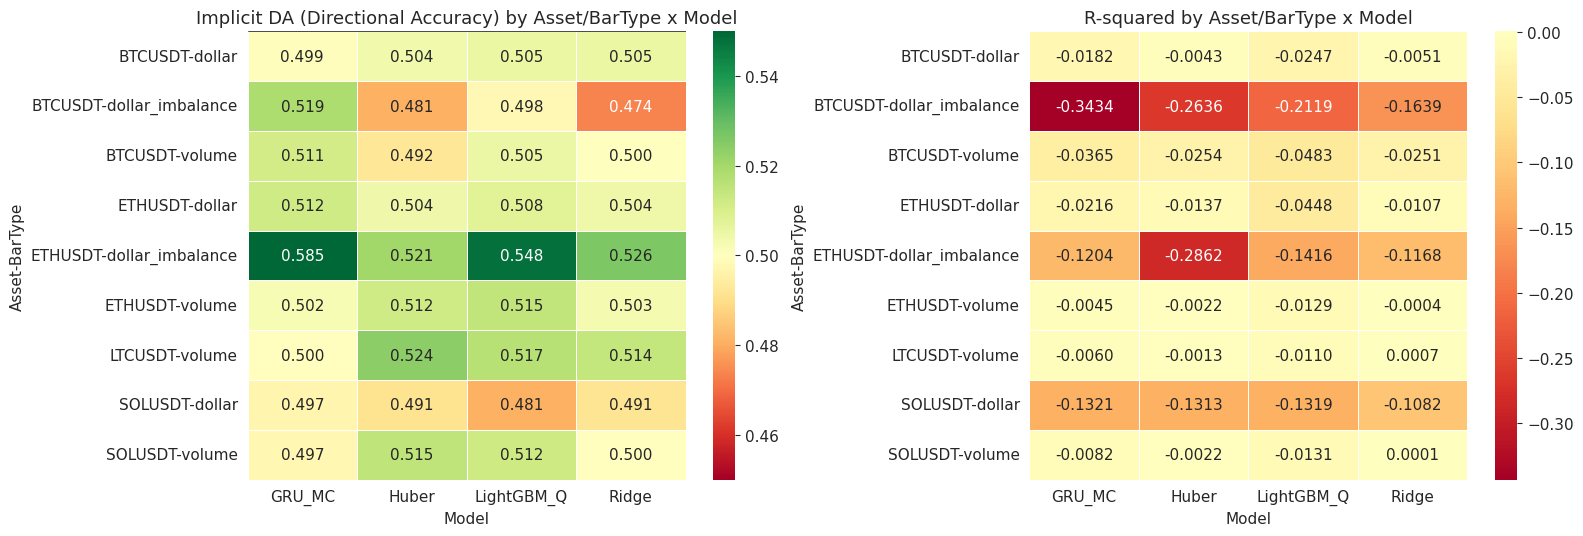

Saved: research/RC3/figures/rc3_reg_fig01_standalone_metrics.png


In [9]:
from __future__ import annotations

# =============================================================================
# Figure 1: Standalone Metrics Heatmap (DA by Asset x Model)
# =============================================================================
if len(standalone_df) > 0:
    pivot_da = standalone_df.pivot_table(
        index=["Asset", "BarType"],
        columns="Model",
        values="Implicit_DA",
        aggfunc="mean",
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(pivot_da) * 0.5 + 1)))

    # DA heatmap
    sns.heatmap(
        pivot_da,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0.5,
        vmin=0.45,
        vmax=0.55,
        ax=axes[0],
        linewidths=0.5,
    )
    axes[0].set_title("Implicit DA (Directional Accuracy) by Asset/BarType x Model")
    axes[0].axhline(y=0, color="k", linewidth=0.5)

    # R-squared heatmap
    pivot_r2 = standalone_df.pivot_table(
        index=["Asset", "BarType"],
        columns="Model",
        values="R2",
        aggfunc="mean",
    )
    sns.heatmap(
        pivot_r2,
        annot=True,
        fmt=".4f",
        cmap="RdYlGn",
        center=0.0,
        ax=axes[1],
        linewidths=0.5,
    )
    axes[1].set_title("R-squared by Asset/BarType x Model")

    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_reg_fig01_standalone_metrics.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_reg_fig01_standalone_metrics.png'}")
else:
    print("No data for heatmap.")

---
## 4. Naive Benchmark Battery

Three naive baselines every regressor must beat to justify its complexity:

1. **Random Walk** -- predict 0 (no change). This is the null hypothesis: returns are unpredictable.
2. **EWMA** -- exponentially weighted moving average of past returns. Captures simple mean-reversion or momentum.
3. **Historical Mean** -- predict the training-set mean return for all test samples.

If a trained model cannot beat these benchmarks, it has no economic value.

In [11]:
from __future__ import annotations

# =============================================================================
# Naive Benchmark Evaluation
# =============================================================================
EWMA_SPAN = 12  # EWMA half-life in bars

naive_results = {}

for (asset, bar_type), (feature_set, bars_pd) in data_store.items():
    for horizon in [PRIMARY_HORIZON]:
        result = prepare_features_and_targets(feature_set, horizon)
        if result is None:
            continue

        X, y_dir, y_reg, feature_cols, df = result
        n_samples = len(X)
        timestamps = np.arange(n_samples, dtype=np.int64)
        folds = splitter.split(n_samples)

        for naive_name in ["RandomWalk", "EWMA", "HistMean"]:
            all_actuals = []
            all_preds = []
            fold_metrics = []

            for fold in folds:
                y_train = y_reg[list(fold.train_indices)]
                y_test = y_reg[list(fold.test_indices)]

                if naive_name == "RandomWalk":
                    # Predict 0 for all test samples
                    preds = np.zeros_like(y_test)
                elif naive_name == "EWMA":
                    # EWMA of training returns, applied as constant forecast
                    ewma_val = pd.Series(y_train).ewm(span=EWMA_SPAN).mean().iloc[-1]
                    preds = np.full_like(y_test, ewma_val)
                elif naive_name == "HistMean":
                    # Historical mean of training returns
                    hist_mean = np.mean(y_train)
                    preds = np.full_like(y_test, hist_mean)

                metrics = compute_regression_metrics(y_test, preds)
                fold_metrics.append(metrics)
                all_actuals.append(y_test)
                all_preds.append(preds)

            actuals = np.concatenate(all_actuals)
            preds = np.concatenate(all_preds)

            avg_mae = np.mean([m.mae for m in fold_metrics])
            avg_rmse = np.mean([m.rmse for m in fold_metrics])
            avg_r2 = np.mean([m.r_squared for m in fold_metrics])
            avg_da = np.mean([m.implicit_da for m in fold_metrics])

            naive_results[(asset, bar_type, horizon.value, naive_name)] = {
                "avg_mae": avg_mae,
                "avg_rmse": avg_rmse,
                "avg_r2": avg_r2,
                "avg_da": avg_da,
                "n_samples": len(actuals),
            }

            print(
                f"  {asset}/{bar_type}/{naive_name:12s}: MAE={avg_mae:.6f}  "
                f"RMSE={avg_rmse:.6f}  R2={avg_r2:.4f}  DA={avg_da:.4f}"
            )

# Combine into a summary table
naive_rows = []
for (asset, bar_type, horizon, model), res in naive_results.items():
    naive_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Horizon": horizon,
            "Model": model,
            "MAE": res["avg_mae"],
            "RMSE": res["avg_rmse"],
            "R2": res["avg_r2"],
            "Implicit_DA": res["avg_da"],
        }
    )
naive_df = pd.DataFrame(naive_rows)
if len(naive_df) > 0:
    display(Markdown("### Naive Benchmark Summary"))
    display(naive_df.sort_values(["Asset", "BarType", "Model"]).reset_index(drop=True))

# Compare: do trained models beat naive baselines?
if len(standalone_df) > 0 and len(naive_df) > 0:
    display(Markdown("### Model vs Naive Comparison (MAE)"))
    for (asset, bar_type, horizon, model), res in standalone_results.items():
        rw_key = (asset, bar_type, horizon, "RandomWalk")
        if rw_key in naive_results:
            rw_mae = naive_results[rw_key]["avg_mae"]
            model_mae = res["avg_mae"]
            improvement = (rw_mae - model_mae) / rw_mae * 100
            beat = "BEATS" if model_mae < rw_mae else "LOSES to"
            print(
                f"  {asset}/{bar_type}/{model:12s} {beat} RandomWalk: "
                f"MAE={model_mae:.6f} vs {rw_mae:.6f} ({improvement:+.1f}%)"
            )

2026-04-12 18:43:33.463 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5
2026-04-12 18:43:33.466 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.018617, RMSE=0.023835, R²=-0.0004, DA=0.0000
2026-04-12 18:43:33.466 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.013922, RMSE=0.019461, R²=-0.0014, DA=0.0000
2026-04-12 18:43:33.467 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.014500, RMSE=0.019953, R²=-0.0033, DA=0.0000
2026-04-12 18:43:33.467 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.016463, RMSE=0.021289, R²=-0.0030, DA=0.0000
2026-04-12 

2026-04-12 18:43:33.478 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.017393, RMSE=0.022223, R²=-0.0930, DA=0.4650
2026-04-12 18:43:33.479 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1713): MAE=0.016342, RMSE=0.021187, R²=-0.0139, DA=0.5120
2026-04-12 18:43:33.480 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.014058, RMSE=0.019109, R²=-0.0766, DA=0.5088
2026-04-12 18:43:33.481 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.014717, RMSE=0.019726, R²=-0.0852, DA=0.4866
2026-04-12 18:43:33.482 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.016395, RMSE=0.021081, R²=-0.0744, DA=0.

  BTCUSDT/dollar/RandomWalk  : MAE=0.013633  RMSE=0.018256  R2=-0.0011  DA=0.0000
  BTCUSDT/dollar/EWMA        : MAE=0.014400  RMSE=0.018939  R2=-0.0816  DA=0.4902
  BTCUSDT/dollar/HistMean    : MAE=0.013636  RMSE=0.018260  R2=-0.0014  DA=0.5024
  BTCUSDT/dollar_imbalance/RandomWalk  : MAE=0.045662  RMSE=0.056706  R2=-0.0093  DA=0.0000
  BTCUSDT/dollar_imbalance/EWMA        : MAE=0.046000  RMSE=0.057285  R2=-0.0273  DA=0.4983
  BTCUSDT/dollar_imbalance/HistMean    : MAE=0.045887  RMSE=0.056999  R2=-0.0197  DA=0.4822
  BTCUSDT/volume/RandomWalk  : MAE=0.017159  RMSE=0.023593  R2=-0.0033  DA=0.0000
  BTCUSDT/volume/EWMA        : MAE=0.022467  RMSE=0.028065  R2=-0.5619  DA=0.4824
  BTCUSDT/volume/HistMean    : MAE=0.017199  RMSE=0.023615  R2=-0.0056  DA=0.5119
  ETHUSDT/dollar/RandomWalk  : MAE=0.025722  RMSE=0.032990  R2=-0.0003  DA=0.0000
  ETHUSDT/dollar/EWMA        : MAE=0.025733  RMSE=0.033051  R2=-0.0044  DA=0.5166
  ETHUSDT/dollar/HistMean    : MAE=0.025721  RMSE=0.032994  R2=-0.00

2026-04-12 18:43:33.677 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=7964): MAE=0.009333, RMSE=0.012532, R²=-0.0041, DA=0.5211
2026-04-12 18:43:33.679 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=7964): MAE=0.009185, RMSE=0.012303, R²=-0.0089, DA=0.5062
2026-04-12 18:43:33.680 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=7964): MAE=0.007704, RMSE=0.010577, R²=-0.0092, DA=0.5093
2026-04-12 18:43:33.681 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=7964): MAE=0.008255, RMSE=0.011069, R²=-0.0086, DA=0.5107
2026-04-12 18:43:33.683 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=7964): MAE=0.010664, RMSE=0.013405, R²=-0.4476, DA=0.

  ETHUSDT/volume/RandomWalk  : MAE=0.008825  RMSE=0.011780  R2=-0.0003  DA=0.0006
  ETHUSDT/volume/EWMA        : MAE=0.009540  RMSE=0.012477  R2=-0.1320  DA=0.5044
  ETHUSDT/volume/HistMean    : MAE=0.008825  RMSE=0.011780  R2=-0.0003  DA=0.5076
  LTCUSDT/volume/RandomWalk  : MAE=0.009480  RMSE=0.012641  R2=-0.0001  DA=0.0083
  LTCUSDT/volume/EWMA        : MAE=0.009872  RMSE=0.013063  R2=-0.0722  DA=0.4913
  LTCUSDT/volume/HistMean    : MAE=0.009480  RMSE=0.012641  R2=-0.0002  DA=0.4959
  SOLUSDT/dollar/RandomWalk  : MAE=0.053281  RMSE=0.069073  R2=-0.0027  DA=0.0000
  SOLUSDT/dollar/EWMA        : MAE=0.053563  RMSE=0.069555  R2=-0.0205  DA=0.5104
  SOLUSDT/dollar/HistMean    : MAE=0.053372  RMSE=0.069153  R2=-0.0052  DA=0.4803


...

  SOLUSDT/volume/RandomWalk  : MAE=0.008249  RMSE=0.011511  R2=-0.0001  DA=0.0093
  SOLUSDT/volume/EWMA        : MAE=0.008497  RMSE=0.011726  R2=-0.0448  DA=0.4980
  SOLUSDT/volume/HistMean    : MAE=0.008250  RMSE=0.011511  R2=-0.0002  DA=0.4971


### Naive Benchmark Summary

,Asset,BarType,Horizon,Model,MAE,RMSE,R2,Implicit_DA
0,BTCUSDT,dollar,h1,EWMA,0.0144,0.0189,-0.0816,0.4902
1,BTCUSDT,dollar,h1,HistMean,0.0136,0.0183,-0.0014,0.5024
2,BTCUSDT,dollar,h1,RandomWalk,0.0136,0.0183,-0.0011,0.0000
3,BTCUSDT,dollar_imbalance,h1,EWMA,0.0460,0.0573,-0.0273,0.4983
4,BTCUSDT,dollar_imbalance,h1,HistMean,0.0459,0.0570,-0.0197,0.4822
5,BTCUSDT,dollar_imbalance,h1,RandomWalk,0.0457,0.0567,-0.0093,0.0000
6,BTCUSDT,volume,h1,EWMA,0.0225,0.0281,-0.5619,0.4824
7,BTCUSDT,volume,h1,HistMean,0.0172,0.0236,-0.0056,0.5119
8,BTCUSDT,volume,h1,RandomWalk,0.0172,0.0236,-0.0033,0.0000
9,ETHUSDT,dollar,h1,EWMA,0.0257,0.0331,-0.0044,0.5166


### Model vs Naive Comparison (MAE)

  BTCUSDT/dollar/Ridge        LOSES to RandomWalk: MAE=0.013685 vs 0.013633 (-0.4%)
  BTCUSDT/dollar/Huber        LOSES to RandomWalk: MAE=0.013667 vs 0.013633 (-0.3%)
  BTCUSDT/dollar/LightGBM_Q   LOSES to RandomWalk: MAE=0.013833 vs 0.013633 (-1.5%)
  BTCUSDT/dollar/GRU_MC       LOSES to RandomWalk: MAE=0.013726 vs 0.013633 (-0.7%)
  BTCUSDT/dollar_imbalance/Ridge        LOSES to RandomWalk: MAE=0.048419 vs 0.045662 (-6.0%)
  BTCUSDT/dollar_imbalance/Huber        LOSES to RandomWalk: MAE=0.050194 vs 0.045662 (-9.9%)
  BTCUSDT/dollar_imbalance/LightGBM_Q   LOSES to RandomWalk: MAE=0.049200 vs 0.045662 (-7.7%)
  BTCUSDT/dollar_imbalance/GRU_MC       LOSES to RandomWalk: MAE=0.051057 vs 0.045662 (-11.8%)
  BTCUSDT/volume/Ridge        LOSES to RandomWalk: MAE=0.017452 vs 0.017159 (-1.7%)
  BTCUSDT/volume/Huber        LOSES to RandomWalk: MAE=0.017435 vs 0.017159 (-1.6%)
  BTCUSDT/volume/LightGBM_Q   LOSES to RandomWalk: MAE=0.017572 vs 0.017159 (-2.4%)
  BTCUSDT/volume/GRU_MC       LOSES

---
## 5. Shuffled-Labels Sanity Check for Regressors

**Ojala & Garriga (2010)**: If we permute the target labels, any trained model should achieve
R-squared near 0 and DA near 50%. If it does not, the pipeline has a leakage bug.

We adapt the classifier shuffled-labels check for regressors:
- Permute `y_reg` (forward log returns)
- Train each regressor on the permuted targets
- Verify R-squared collapses to near 0 and DA stays near 50%

In [13]:
from __future__ import annotations

# =============================================================================
# Shuffled-Labels Sanity Check for Regressors
# =============================================================================
N_PERMUTATIONS = 3  # Keep low for speed (3 perms x folds x models)
SHUFFLED_DA_LOWER = 0.45
SHUFFLED_DA_UPPER = 0.55
SHUFFLED_R2_UPPER = 0.05  # R2 should be near 0

# Pick one representative cell for the sanity check (BTCUSDT/dollar)
sanity_key = None
for key in data_store:
    if key[0] == "BTCUSDT" and key[1] == "dollar":
        sanity_key = key
        break
if sanity_key is None and len(data_store) > 0:
    sanity_key = list(data_store.keys())[0]

shuffled_results = {}
if sanity_key is not None:
    feature_set, bars_pd = data_store[sanity_key]
    result = prepare_features_and_targets(feature_set, PRIMARY_HORIZON)
    if result is not None:
        X, y_dir, y_reg, feature_cols, df = result
        n_samples = len(X)
        timestamps = np.arange(n_samples, dtype=np.int64)
        folds = splitter.split(n_samples)

        rng = np.random.default_rng(RANDOM_SEED)

        # Only test Ridge and LightGBM (GRU is too slow for permutation tests)
        for model_name in ["Ridge", "LightGBM_Q"]:
            perm_das = []
            perm_r2s = []

            for perm_idx in range(N_PERMUTATIONS):
                y_permuted = rng.permutation(y_reg).astype(np.float64)
                eval_result = evaluate_regressor_on_folds(model_name, X, y_permuted, folds)

                if eval_result is not None:
                    _, _, _, fold_metrics = eval_result
                    avg_da = np.mean([m.implicit_da for m in fold_metrics])
                    avg_r2 = np.mean([m.r_squared for m in fold_metrics])
                    perm_das.append(avg_da)
                    perm_r2s.append(avg_r2)

            if perm_das:
                mean_da = np.mean(perm_das)
                mean_r2 = np.mean(perm_r2s)
                da_pass = SHUFFLED_DA_LOWER <= mean_da <= SHUFFLED_DA_UPPER
                r2_pass = mean_r2 < SHUFFLED_R2_UPPER
                overall_pass = da_pass and r2_pass

                shuffled_results[model_name] = {
                    "mean_da": mean_da,
                    "mean_r2": mean_r2,
                    "da_pass": da_pass,
                    "r2_pass": r2_pass,
                    "overall_pass": overall_pass,
                    "per_perm_da": perm_das,
                    "per_perm_r2": perm_r2s,
                }

                status = "PASS" if overall_pass else "FAIL"
                print(
                    f"  {model_name}: mean_DA={mean_da:.4f} (pass={da_pass})  "
                    f"mean_R2={mean_r2:.4f} (pass={r2_pass})  -> {status}"
                )

# Summary
display(Markdown("### Shuffled-Labels Sanity Check Summary"))
if shuffled_results:
    all_pass = all(r["overall_pass"] for r in shuffled_results.values())
    for name, res in shuffled_results.items():
        print(
            f"  {name}: DA={res['mean_da']:.4f}  R2={res['mean_r2']:.4f}  "
            f"-> {'PASS' if res['overall_pass'] else 'FAIL'}"
        )
    print(f"\n  Overall pipeline integrity: {'PASS' if all_pass else 'FAIL'}")
else:
    print("  No shuffled-labels results (no data available).")

2026-04-12 18:44:57.722 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5
2026-04-12 18:44:57.727 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3421 samples | residual_std=0.018242
2026-04-12 18:44:57.728 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.014055, RMSE=0.018962, R²=-0.0105, DA=0.5105
2026-04-12 18:44:57.730 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.018264
2026-04-12 18:44:57.731 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.013891, RMSE=0.018861, R²=-0.0047, DA=0.5093
2026-04-12 18:44:57.734 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples

2026-04-12 18:44:57.737 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.018207
2026-04-12 18:44:57.738 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.014032, RMSE=0.018976, R²=-0.0087, DA=0.5134
2026-04-12 18:44:57.741 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3421 samples | residual_std=0.018066
2026-04-12 18:44:57.742 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1713): MAE=0.014176, RMSE=0.019256, R²=-0.0100, DA=0.4945
2026-04-12 18:44:57.746 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3420 samples | residual_std=0.018610
2026-04-12 18:44:57.746 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.0134

  Ridge: mean_DA=0.5012 (pass=True)  mean_R2=-0.0068 (pass=True)  -> PASS


2026-04-12 18:44:58.264 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3421 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:44:58.285 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.013989, RMSE=0.018826, R²=-0.0361, DA=0.5006
2026-04-12 18:44:58.646 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3414 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:44:58.665 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_regression_metrics:232 - Regression metrics (n=1714): MAE=0.013576, RMSE=0.018407, R²=-0.0342, DA=0.4947
2026-04-12 18:44:59.012 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3414 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:44:59.033 | DE

  LightGBM_Q: mean_DA=0.4934 (pass=True)  mean_R2=-0.0250 (pass=True)  -> PASS


### Shuffled-Labels Sanity Check Summary

  Ridge: DA=0.5012  R2=-0.0068  -> PASS
  LightGBM_Q: DA=0.4934  R2=-0.0250  -> PASS

  Overall pipeline integrity: PASS


---
## 6. Pipeline Evaluation: Classifier + Regressor Combined

This is the core two-track evaluation:
1. **Classifier** predicts direction (SIDE): +1 or -1
2. **Regressor** predicts magnitude (SIZE): forward log return

Pipeline metrics:
- **DC-MAE / DC-RMSE**: Magnitude error restricted to samples where the classifier got direction right
- **Scatter plots**: Predicted vs actual return, only for correct-direction samples
- **Selection bias**: Compare the distribution of correct-direction samples to the full dataset
- **PDR**: When classifier says "up" AND regressor says "> +1%", how often is realized return positive and > 0.5%?
- **Economic Sharpe**: Combined signal treated as a trading strategy with transaction costs

In [16]:
from __future__ import annotations

# =============================================================================
# Pipeline Evaluation: Classifier + Regressor
# =============================================================================


def make_classifiers(horizon):
    """Create classifier instances for the pipeline evaluation."""
    return {
        "Logistic": LogisticBaseline(LogisticConfig(c=1.0), horizon),
        "LightGBM_Clf": GradientBoostingClassifier(
            GradientBoostingClassifierConfig(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
            ),
            horizon,
        ),
    }


CLASSIFIER_NAMES = ["Logistic", "LightGBM_Clf"]
REGRESSOR_NAMES_PIPELINE = ["Ridge", "LightGBM_Q"]  # Skip GRU for pipeline speed

pipeline_results = {}

for (asset, bar_type), (feature_set, bars_pd) in data_store.items():
    for horizon in [PRIMARY_HORIZON]:
        result = prepare_features_and_targets(feature_set, horizon)
        if result is None:
            continue

        X, y_dir, y_reg, feature_cols, df = result
        n_samples = len(X)
        timestamps = np.arange(n_samples, dtype=np.int64)
        folds = splitter.split(n_samples)

        print(f"\n{'=' * 70}")
        print(f"Pipeline: {asset} / {bar_type} / {horizon.value}")

        for clf_name in CLASSIFIER_NAMES:
            for reg_name in REGRESSOR_NAMES_PIPELINE:
                all_actuals = []
                all_reg_preds = []
                all_clf_dirs = []
                all_dir_correct = []

                for fold_idx, fold in enumerate(folds):
                    try:
                        train_idx = list(fold.train_indices)
                        test_idx = list(fold.test_indices)

                        # Scale features
                        scaler = StandardScaler()
                        X_train = scaler.fit_transform(X[train_idx])
                        X_test = scaler.transform(X[test_idx])
                        y_dir_train = y_dir[train_idx]
                        y_dir_test = y_dir[test_idx]
                        y_reg_train = y_reg[train_idx]
                        y_reg_test = y_reg[test_idx]

                        # Train classifier
                        classifiers = make_classifiers(horizon)
                        clf = classifiers[clf_name]
                        clf.fit(X_train, y_dir_train)
                        clf_forecasts = clf.predict(X_test)
                        clf_dirs = np.array([f.predicted_direction for f in clf_forecasts], dtype=np.float64)

                        # Train regressor
                        regressors = make_regressors()
                        reg = regressors[reg_name]
                        reg.fit(X_train, y_reg_train)
                        reg_pred = reg.predict(X_test)
                        reg_preds = reg_pred.mean.astype(np.float64)

                        # Align GRU output
                        n_pred = len(reg_preds)
                        if n_pred < len(y_reg_test):
                            y_reg_test = y_reg_test[-n_pred:]
                            y_dir_test = y_dir_test[-n_pred:]
                            clf_dirs = clf_dirs[-n_pred:]

                        # Direction correctness mask
                        dir_correct = clf_dirs == y_dir_test

                        all_actuals.append(y_reg_test)
                        all_reg_preds.append(reg_preds)
                        all_clf_dirs.append(clf_dirs)
                        all_dir_correct.append(dir_correct)

                    except Exception as e:
                        print(f"  Fold {fold_idx} {clf_name}+{reg_name}: {e}")
                        continue

                if not all_actuals:
                    continue

                actuals = np.concatenate(all_actuals)
                reg_preds = np.concatenate(all_reg_preds)
                clf_dirs = np.concatenate(all_clf_dirs)
                dir_correct = np.concatenate(all_dir_correct)

                n_total = len(actuals)
                n_correct = int(np.sum(dir_correct))
                da = n_correct / n_total if n_total > 0 else 0.0

                # DC-MAE and DC-RMSE
                dc_mae_val = compute_dc_mae(actuals, reg_preds, dir_correct) if n_correct > 0 else float("nan")
                dc_rmse_val = compute_dc_rmse(actuals, reg_preds, dir_correct) if n_correct > 0 else float("nan")

                # PDR
                pdr_val = compute_pdr(
                    actuals, reg_preds, dir_correct, magnitude_threshold=0.005, realized_threshold=0.003
                )

                # Economic Sharpe
                eco_sharpe = compute_economic_sharpe(
                    actuals,
                    reg_preds,
                    clf_dirs,
                    transaction_cost=ROUND_TRIP_COST / 2,  # one-way cost
                )

                # Full-sample regression metrics for comparison
                full_metrics = compute_regression_metrics(actuals, reg_preds)

                pipeline_results[(asset, bar_type, horizon.value, clf_name, reg_name)] = {
                    "actuals": actuals,
                    "reg_preds": reg_preds,
                    "clf_dirs": clf_dirs,
                    "dir_correct": dir_correct,
                    "da": da,
                    "dc_mae": dc_mae_val,
                    "dc_rmse": dc_rmse_val,
                    "pdr": pdr_val,
                    "eco_sharpe": eco_sharpe,
                    "full_mae": full_metrics.mae,
                    "full_rmse": full_metrics.rmse,
                    "full_r2": full_metrics.r_squared,
                    "implicit_da": full_metrics.implicit_da,
                    "n_total": n_total,
                    "n_correct": n_correct,
                }

                print(
                    f"  {clf_name}+{reg_name}: DA={da:.4f}  DC-MAE={dc_mae_val:.6f}  "
                    f"DC-RMSE={dc_rmse_val:.6f}  PDR={pdr_val:.4f}  "
                    f"EcoSharpe={eco_sharpe:.4f}  (n_correct={n_correct}/{n_total})"
                )

print(f"\nTotal pipeline results: {len(pipeline_results)}")

2026-04-12 18:49:06.709 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5


2026-04-12 18:49:06.758 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5329 | C=1.0
2026-04-12 18:49:06.768 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3421 samples | residual_std=0.015068
2026-04-12 18:49:06.779 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5275 | C=1.0
2026-04-12 18:49:06.790 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.017897
2026-04-12 18:49:06.806 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5243 | C=1.0
2026-04-12 18:49:06.817 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.017602
2026-04-12 18:49:06.829 | INFO     | src.app.forecasting.applicatio


Pipeline: BTCUSDT / dollar / h1


2026-04-12 18:49:06.919 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5394 | C=1.0
2026-04-12 18:49:06.930 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3413 samples | residual_std=0.017391
2026-04-12 18:49:06.955 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5348 | C=1.0
2026-04-12 18:49:06.965 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3420 samples | residual_std=0.017542
2026-04-12 18:49:06.977 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5404 | C=1.0
2026-04-12 18:49:06.987 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3420 samples | residual_std=0.020560
2026-04-12 18:49:07.004 | INFO     | src.app.forecasting.applicatio

  Logistic+Ridge: DA=0.5044  DC-MAE=0.012966  DC-RMSE=0.017877  PDR=0.9217  EcoSharpe=-0.0239  (n_correct=12965/25705)


...

  Logistic+LightGBM_Q: DA=0.5209  DC-MAE=0.007445  DC-RMSE=0.010749  PDR=0.8160  EcoSharpe=-0.0460  (n_correct=122488/235160)


2026-04-12 18:52:33.499 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31348 samples | train_acc=0.6498 | n_estimators=300 | calibration=sigmoid
2026-04-12 18:52:33.650 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 31348 samples | residual_std=0.009361
2026-04-12 18:52:34.643 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.6768 | n_estimators=300 | calibration=sigmoid
2026-04-12 18:52:34.785 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 31341 samples | residual_std=0.010319
2026-04-12 18:52:35.753 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.6492 | n_estimators=300 | calibration=sigmoid
2026-04-12 18:52:35.895 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - R

  LightGBM_Clf+Ridge: DA=0.5154  DC-MAE=0.007981  DC-RMSE=0.011341  PDR=0.8444  EcoSharpe=-0.0469  (n_correct=121200/235160)


2026-04-12 18:52:50.701 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31348 samples | train_acc=0.6498 | n_estimators=300 | calibration=sigmoid
2026-04-12 18:52:52.084 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31348 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:52:53.233 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.6768 | n_estimators=300 | calibration=sigmoid
2026-04-12 18:52:54.647 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31341 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:52:55.793 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.6492 | n_estimators=300 | calibration=sigmoid
2026-0

  LightGBM_Clf+LightGBM_Q: DA=0.5154  DC-MAE=0.007549  DC-RMSE=0.010977  PDR=0.8419  EcoSharpe=-0.0469  (n_correct=121200/235160)

Total pipeline results: 36


In [17]:
from __future__ import annotations

# =============================================================================
# Pipeline Summary Table
# =============================================================================
pipe_rows = []
for (asset, bar_type, horizon, clf, reg), res in pipeline_results.items():
    pipe_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Horizon": horizon,
            "Classifier": clf,
            "Regressor": reg,
            "Clf_DA": res["da"],
            "DC_MAE": res["dc_mae"],
            "DC_RMSE": res["dc_rmse"],
            "Full_MAE": res["full_mae"],
            "Full_RMSE": res["full_rmse"],
            "Full_R2": res["full_r2"],
            "Reg_DA": res["implicit_da"],
            "PDR": res["pdr"],
            "EcoSharpe": res["eco_sharpe"],
            "N_Correct": res["n_correct"],
            "N_Total": res["n_total"],
        }
    )

pipeline_df = pd.DataFrame(pipe_rows)
if len(pipeline_df) > 0:
    display(Markdown("### Pipeline Results: Classifier + Regressor"))
    display(pipeline_df.sort_values(["Asset", "BarType", "Classifier", "Regressor"]).reset_index(drop=True))

    # Selection bias characterization
    display(Markdown("### Selection Bias: Correct-Direction Subset vs Full"))
    for key, res in pipeline_results.items():
        actuals = res["actuals"]
        dir_correct = res["dir_correct"]
        correct_actuals = actuals[dir_correct]
        incorrect_actuals = actuals[~dir_correct]

        full_std = np.std(actuals)
        correct_std = np.std(correct_actuals) if len(correct_actuals) > 1 else 0.0
        correct_mean = np.mean(np.abs(correct_actuals)) if len(correct_actuals) > 0 else 0.0
        full_mean = np.mean(np.abs(actuals))

        label = f"{key[0]}/{key[1]}/{key[3]}+{key[4]}"
        print(f"  {label}:")
        print(f"    Full:    mean|ret|={full_mean:.6f}  std={full_std:.6f}  n={len(actuals)}")
        print(
            f"    Correct: mean|ret|={correct_mean:.6f}  std={correct_std:.6f}  "
            f"n={len(correct_actuals)} ({len(correct_actuals) / len(actuals) * 100:.1f}%)"
        )
else:
    print("No pipeline results.")

### Pipeline Results: Classifier + Regressor

,Asset,BarType,Horizon,Classifier,Regressor,Clf_DA,DC_MAE,DC_RMSE,Full_MAE,Full_RMSE,Full_R2,Reg_DA,PDR,EcoSharpe,N_Correct,N_Total
0,BTCUSDT,dollar,h1,LightGBM_Clf,LightGBM_Q,0.5061,0.0134,0.0182,0.0138,0.0187,-0.0205,0.5051,0.5996,-0.0069,13009,25705
1,BTCUSDT,dollar,h1,LightGBM_Clf,Ridge,0.5061,0.0134,0.0182,0.0137,0.0185,-0.0030,0.5052,0.6756,-0.0069,13009,25705
2,BTCUSDT,dollar,h1,Logistic,LightGBM_Q,0.5044,0.0133,0.0182,0.0138,0.0187,-0.0205,0.5051,0.6381,-0.0239,12965,25705
3,BTCUSDT,dollar,h1,Logistic,Ridge,0.5044,0.0130,0.0179,0.0137,0.0185,-0.0030,0.5052,0.9217,-0.0239,12965,25705
4,BTCUSDT,dollar_imbalance,h1,LightGBM_Clf,LightGBM_Q,0.4686,0.0491,0.0620,0.0492,0.0619,-0.1568,0.4979,0.4969,-0.0319,991,2115
5,BTCUSDT,dollar_imbalance,h1,LightGBM_Clf,Ridge,0.4686,0.0482,0.0611,0.0484,0.0614,-0.1376,0.4738,0.5111,-0.0319,991,2115
6,BTCUSDT,dollar_imbalance,h1,Logistic,LightGBM_Q,0.4757,0.0441,0.0569,0.0492,0.0619,-0.1568,0.4979,0.6491,-0.0463,1006,2115
7,BTCUSDT,dollar_imbalance,h1,Logistic,Ridge,0.4757,0.0382,0.0505,0.0484,0.0614,-0.1376,0.4738,0.7985,-0.0463,1006,2115
8,BTCUSDT,volume,h1,LightGBM_Clf,LightGBM_Q,0.5061,0.0177,0.0247,0.0176,0.0247,-0.0390,0.5049,0.4069,-0.0120,7890,15590
9,BTCUSDT,volume,h1,LightGBM_Clf,Ridge,0.5061,0.0169,0.0240,0.0175,0.0244,-0.0212,0.5003,0.4855,-0.0120,7890,15590


### Selection Bias: Correct-Direction Subset vs Full

  BTCUSDT/dollar/Logistic+Ridge:
    Full:    mean|ret|=0.013633  std=0.018487  n=25705
    Correct: mean|ret|=0.013722  std=0.018208  n=12965 (50.4%)
  BTCUSDT/dollar/Logistic+LightGBM_Q:
    Full:    mean|ret|=0.013633  std=0.018487  n=25705
    Correct: mean|ret|=0.013722  std=0.018208  n=12965 (50.4%)
  BTCUSDT/dollar/LightGBM_Clf+Ridge:
    Full:    mean|ret|=0.013633  std=0.018487  n=25705
    Correct: mean|ret|=0.013619  std=0.015484  n=13009 (50.6%)
  BTCUSDT/dollar/LightGBM_Clf+LightGBM_Q:
    Full:    mean|ret|=0.013633  std=0.018487  n=25705
    Correct: mean|ret|=0.013619  std=0.015484  n=13009 (50.6%)
  BTCUSDT/dollar_imbalance/Logistic+Ridge:
    Full:    mean|ret|=0.045667  std=0.057568  n=2115
    Correct: mean|ret|=0.046076  std=0.057840  n=1006 (47.6%)
  BTCUSDT/dollar_imbalance/Logistic+LightGBM_Q:
    Full:    mean|ret|=0.045667  std=0.057568  n=2115
    Correct: mean|ret|=0.046076  std=0.057840  n=1006 (47.6%)
  BTCUSDT/dollar_imbalance/LightGBM_Clf+Ridge:
    Full

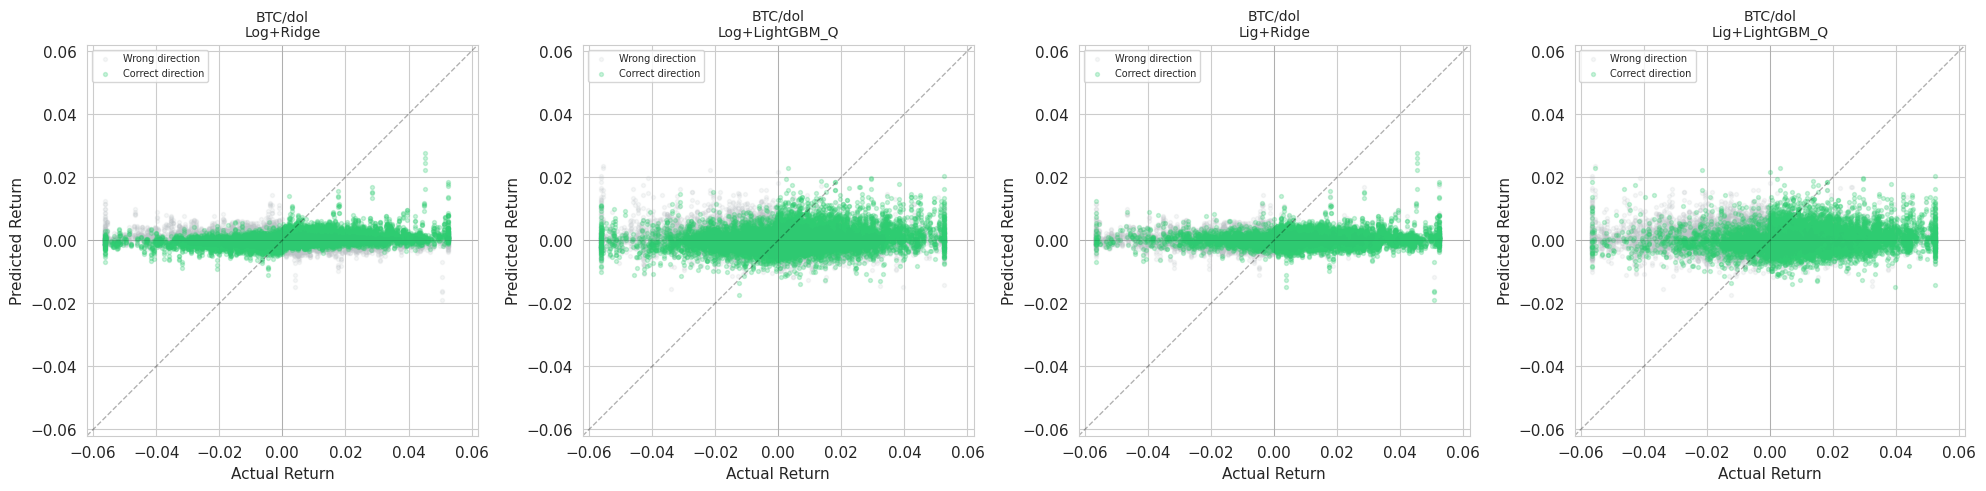

Saved: research/RC3/figures/rc3_reg_fig02_scatter_pred_vs_actual.png


In [18]:
from __future__ import annotations

# =============================================================================
# Figure 2: Scatter Plots -- Predicted vs Actual (correct-direction only)
# =============================================================================
if pipeline_results:
    # Select up to 4 representative combos for scatter plots
    scatter_keys = list(pipeline_results.keys())[:4]

    n_plots = len(scatter_keys)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    for ax, key in zip(axes, scatter_keys):
        res = pipeline_results[key]
        actuals = res["actuals"]
        preds = res["reg_preds"]
        dir_correct = res["dir_correct"]

        # Plot all samples in light gray
        ax.scatter(actuals[~dir_correct], preds[~dir_correct], alpha=0.15, s=8, c="#bdc3c7", label="Wrong direction")
        # Plot correct-direction in color
        ax.scatter(actuals[dir_correct], preds[dir_correct], alpha=0.25, s=8, c="#2ecc71", label="Correct direction")

        # Perfect prediction line
        lim = max(np.abs(actuals).max(), np.abs(preds).max()) * 1.1
        ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.3, linewidth=1)
        ax.axhline(0, color="k", alpha=0.2, linewidth=0.5)
        ax.axvline(0, color="k", alpha=0.2, linewidth=0.5)

        label = f"{key[0][:3]}/{key[1][:3]}\n{key[3][:3]}+{key[4]}"
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Actual Return")
        ax.set_ylabel("Predicted Return")
        ax.legend(fontsize=7, loc="upper left")
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")

    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_reg_fig02_scatter_pred_vs_actual.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_reg_fig02_scatter_pred_vs_actual.png'}")
else:
    print("No pipeline results for scatter plots.")

---
## 7. Uncertainty Evaluation

Evaluate the quality of probabilistic forecasts:

1. **CRPS (Continuous Ranked Probability Score)** -- proper scoring rule for distributional forecasts.
   Uses the Gaussian closed-form (Gneiting & Raftery 2007) with (mean, std) from each model.
2. **Calibration / Reliability Diagrams** -- for LightGBM quantile predictions: does the 5th percentile
   actually contain 5% of observations below it?
3. **Conformal Intervals (ACI)** -- Adaptive Conformal Inference (Gibbs & Candes 2021) with online
   alpha adaptation. Reports coverage overall and per volatility regime.
4. **Interval Sharpness** -- narrower intervals are better at the same coverage level.

In [19]:
from __future__ import annotations

# =============================================================================
# 7.1 CRPS Evaluation
# =============================================================================
crps_results = {}

for (asset, bar_type, horizon, model), res in standalone_results.items():
    actuals = res["actuals"]
    preds = res["preds"]
    stds = res["stds"]

    # Ensure stds are positive (floor at a small epsilon)
    stds_safe = np.maximum(stds, 1e-10)

    crps = compute_crps_gaussian(actuals, preds, stds_safe)
    crps_results[(asset, bar_type, horizon, model)] = {
        "mean_crps": crps.mean_crps,
        "per_sample": crps.per_sample_crps,
    }

# CRPS summary table
crps_rows = []
for (asset, bar_type, horizon, model), res in crps_results.items():
    crps_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Horizon": horizon,
            "Model": model,
            "CRPS": res["mean_crps"],
        }
    )

crps_df = pd.DataFrame(crps_rows)
if len(crps_df) > 0:
    display(Markdown("### CRPS (Gaussian Closed-Form) by Model"))
    pivot_crps = crps_df.pivot_table(
        index=["Asset", "BarType"],
        columns="Model",
        values="CRPS",
        aggfunc="mean",
    )
    display(pivot_crps)

    # Best CRPS per cell
    best_crps = crps_df.loc[crps_df.groupby(["Asset", "BarType"])["CRPS"].idxmin()]
    display(Markdown("### Best CRPS per Asset/BarType"))
    display(best_crps[["Asset", "BarType", "Model", "CRPS"]])
else:
    print("No CRPS results.")

2026-04-12 18:56:18.671 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_crps_gaussian:318 - CRPS Gaussian (n=25705): mean_crps=0.010244
2026-04-12 18:56:18.673 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_crps_gaussian:318 - CRPS Gaussian (n=25705): mean_crps=0.010236
2026-04-12 18:56:18.674 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_crps_gaussian:318 - CRPS Gaussian (n=25705): mean_crps=0.010259
2026-04-12 18:56:18.676 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_crps_gaussian:318 - CRPS Gaussian (n=25405): mean_crps=0.012021
2026-04-12 18:56:18.676 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_crps_gaussian:318 - CRPS Gaussian (n=2115): mean_crps=0.034811
2026-04-12 18:56:18.677 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_crps_gaussian:318 - CRPS Gaussian (n=2115): mean_crps=0.036142
2026-04-12 18:56:18.678 | DEBUG    | src.a

### CRPS (Gaussian Closed-Form) by Model

Model                     GRU_MC  Huber  LightGBM_Q  Ridge
Asset   BarType                                           
BTCUSDT dollar            0.0120 0.0102      0.0103 0.0102
        dollar_imbalance  0.0375 0.0361      0.0371 0.0348
        volume            0.0147 0.0135      0.0131 0.0135
ETHUSDT dollar            0.0220 0.0187      0.0192 0.0186
        dollar_imbalance  0.0626 0.0608      0.0595 0.0568
        volume            0.0084 0.0065      0.0065 0.0065
LTCUSDT volume            0.0090 0.0070      0.0070 0.0070
SOLUSDT dollar            0.0427 0.0429      0.0433 0.0425
        volume            0.0078 0.0063      0.0061 0.0063

### Best CRPS per Asset/BarType

,Asset,BarType,Model,CRPS
1,BTCUSDT,dollar,Huber,0.0102
4,BTCUSDT,dollar_imbalance,Ridge,0.0348
10,BTCUSDT,volume,LightGBM_Q,0.0131
12,ETHUSDT,dollar,Ridge,0.0186
16,ETHUSDT,dollar_imbalance,Ridge,0.0568
22,ETHUSDT,volume,LightGBM_Q,0.0065
26,LTCUSDT,volume,LightGBM_Q,0.0070
28,SOLUSDT,dollar,Ridge,0.0425
34,SOLUSDT,volume,LightGBM_Q,0.0061


2026-04-12 18:59:28.447 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5


2026-04-12 18:59:28.832 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3421 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:59:29.209 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3414 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:59:29.594 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3414 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:59:30.004 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3414 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:59:30.398 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 3421 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 18:59:30.784 | INFO     | src.app.forec

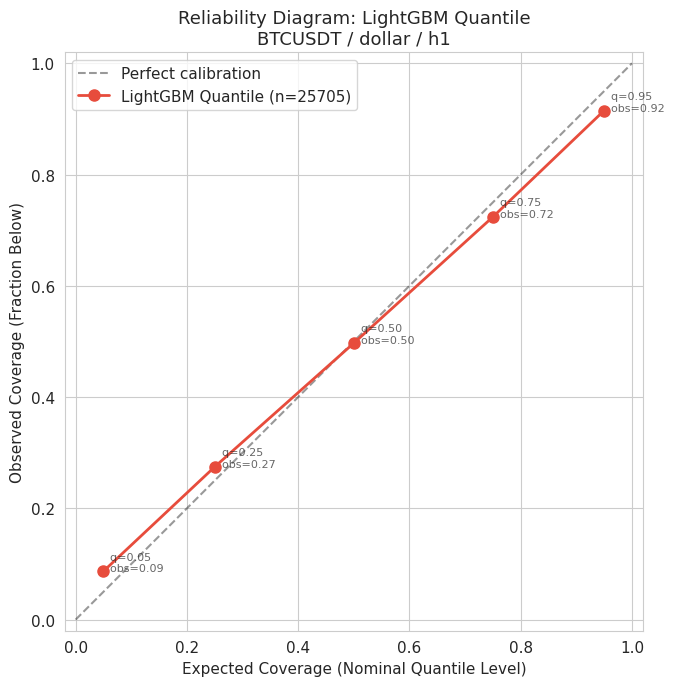

Saved: research/RC3/figures/rc3_reg_fig03_reliability_diagram.png
Max calibration error: 0.0370


In [22]:
from __future__ import annotations

# =============================================================================
# 7.2 Calibration / Reliability Diagrams (LightGBM Quantile Only)
# =============================================================================
from src.app.forecasting.domain.value_objects import QuantilePrediction

# For reliability diagrams, we need quantile predictions from LightGBM
# Re-run LightGBM on one representative cell to get quantile outputs
reliability_results = {}

if sanity_key is not None:
    feature_set, bars_pd = data_store[sanity_key]
    result = prepare_features_and_targets(feature_set, PRIMARY_HORIZON)
    if result is not None:
        X, y_dir, y_reg, feature_cols, df = result
        timestamps = np.arange(len(X), dtype=np.int64)
        folds = splitter.split(len(X))

        all_quantile_values = []
        all_actuals_rel = []

        for fold in folds:
            train_idx = list(fold.train_indices)
            test_idx = list(fold.test_indices)

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X[train_idx])
            X_test = scaler.transform(X[test_idx])

            lgbm = GradientBoostingRegressor(
                GradientBoostingConfig(
                    quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=5,
                )
            )
            lgbm.fit(X_train, y_reg[train_idx])
            qpred = lgbm.predict_quantiles(X_test)
            all_quantile_values.append(qpred.values)
            all_actuals_rel.append(y_reg[test_idx])

        # Concatenate across folds
        cat_qvalues = np.concatenate(all_quantile_values, axis=0)
        cat_actuals = np.concatenate(all_actuals_rel)

        combined_qpred = QuantilePrediction(
            quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
            values=cat_qvalues,
        )

        rel_diagram = compute_reliability_diagram(combined_qpred, cat_actuals)

        # Plot reliability diagram
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
        ax.plot(
            rel_diagram.expected_coverage,
            rel_diagram.observed_coverage,
            "o-",
            color="#e74c3c",
            markersize=8,
            linewidth=2,
            label=f"LightGBM Quantile (n={rel_diagram.n_samples})",
        )

        for i, q in enumerate(rel_diagram.expected_coverage):
            obs = rel_diagram.observed_coverage[i]
            ax.annotate(f"  q={q:.2f}\n  obs={obs:.2f}", (q, obs), fontsize=8, alpha=0.7)

        ax.set_xlabel("Expected Coverage (Nominal Quantile Level)")
        ax.set_ylabel("Observed Coverage (Fraction Below)")
        ax.set_title(
            f"Reliability Diagram: LightGBM Quantile\n{sanity_key[0]} / {sanity_key[1]} / {PRIMARY_HORIZON.value}"
        )
        ax.legend()
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_aspect("equal")

        plt.tight_layout()
        fig.savefig(FIG_DIR / "rc3_reg_fig03_reliability_diagram.png")
        plt.show()
        print(f"Saved: {FIG_DIR / 'rc3_reg_fig03_reliability_diagram.png'}")

        # Max calibration error
        max_cal_error = float(np.max(np.abs(rel_diagram.expected_coverage - rel_diagram.observed_coverage)))
        print(f"Max calibration error: {max_cal_error:.4f}")
else:
    print("No data for reliability diagram.")

In [23]:
from __future__ import annotations

# =============================================================================
# 7.3 Conformal Intervals (ACI) + Per-Regime Coverage
# =============================================================================
conformal_results = {}

for (asset, bar_type, horizon, model), res in standalone_results.items():
    actuals = res["actuals"]
    preds = res["preds"]
    n = len(actuals)

    if n < 50:
        continue

    # Split into calibration (first 60%) and test (last 40%)
    n_cal = int(n * 0.6)
    cal_residuals = actuals[:n_cal] - preds[:n_cal]
    test_actuals = actuals[n_cal:]
    test_preds = preds[n_cal:]

    if len(test_actuals) < 20:
        continue

    # ACI with 90% target coverage
    aci = AdaptiveConformalPredictor(
        ACIConfig(
            target_coverage=0.90,
            gamma=0.005,
            min_alpha=0.01,
            max_alpha=0.50,
        )
    )
    aci.calibrate(cal_residuals)
    interval = aci.predict_interval(test_preds, actuals=test_actuals)

    # Compute interval width (sharpness)
    widths = interval.upper - interval.lower
    mean_width = float(np.mean(widths))
    median_width = float(np.median(widths))

    # Regime coverage using rolling std as volatility proxy
    rolling_std = pd.Series(actuals).rolling(24, min_periods=12).std().values
    test_vol = rolling_std[n_cal:]
    # Handle NaN in early rolling window
    valid_mask = ~np.isnan(test_vol)
    if np.sum(valid_mask) > 20:
        regime_cov = compute_regime_coverage(
            interval.lower[valid_mask],
            interval.upper[valid_mask],
            test_actuals[valid_mask],
            test_vol[valid_mask],
        )
    else:
        regime_cov = None

    conformal_results[(asset, bar_type, horizon, model)] = {
        "coverage": interval.coverage,
        "mean_width": mean_width,
        "median_width": median_width,
        "regime_cov": regime_cov,
        "alpha_history": aci.alpha_history,
        "n_test": len(test_actuals),
    }

# Summary table
conf_rows = []
for key, res in conformal_results.items():
    row = {
        "Asset": key[0],
        "BarType": key[1],
        "Horizon": key[2],
        "Model": key[3],
        "Coverage": res["coverage"],
        "MeanWidth": res["mean_width"],
        "MedianWidth": res["median_width"],
        "N_Test": res["n_test"],
    }
    if res["regime_cov"] is not None:
        row["HighVol_Cov"] = res["regime_cov"].high_vol_coverage
        row["LowVol_Cov"] = res["regime_cov"].low_vol_coverage
    conf_rows.append(row)

conf_df = pd.DataFrame(conf_rows)
if len(conf_df) > 0:
    display(Markdown("### Conformal Interval Coverage & Sharpness"))
    display(conf_df.sort_values(["Asset", "BarType", "Model"]).reset_index(drop=True))

    # Check: is coverage near 90% target?
    display(Markdown("### Coverage vs 90% Target"))
    for _, row in conf_df.iterrows():
        cov = row.get("Coverage", 0.0)
        gap = abs(cov - 0.90) if cov is not None else float("nan")
        status = "OK" if gap < 0.05 else "DRIFT"
        hi_vol = row.get("HighVol_Cov", "N/A")
        lo_vol = row.get("LowVol_Cov", "N/A")
        print(
            f"  {row['Asset']}/{row['BarType']}/{row['Model']}: "
            f"coverage={cov:.4f} ({status})  width={row['MeanWidth']:.6f}  "
            f"high_vol={hi_vol}  low_vol={lo_vol}"
        )
else:
    print("No conformal results.")

2026-04-12 18:59:46.008 | INFO     | src.app.forecasting.application.calibration:calibrate:112 - ACI calibrated on 15423 residuals | score range [0.000002, 0.069542]
2026-04-12 18:59:46.788 | INFO     | src.app.forecasting.application.calibration:compute_regime_coverage:452 - Regime coverage: overall=0.9982 | high_vol=0.9967 (n=5141) | low_vol=0.9998 (n=5141) | threshold=0.014058
2026-04-12 18:59:46.789 | INFO     | src.app.forecasting.application.calibration:calibrate:112 - ACI calibrated on 15423 residuals | score range [0.000001, 0.069853]
2026-04-12 18:59:47.586 | INFO     | src.app.forecasting.application.calibration:compute_regime_coverage:452 - Regime coverage: overall=0.9982 | high_vol=0.9965 (n=5141) | low_vol=1.0000 (n=5141) | threshold=0.014058
2026-04-12 18:59:47.587 | INFO     | src.app.forecasting.application.calibration:calibrate:112 - ACI calibrated on 15423 residuals | score range [0.000000, 0.079073]
2026-04-12 18:59:48.395 | INFO     | src.app.forecasting.application

### Conformal Interval Coverage & Sharpness

,Asset,BarType,Horizon,Model,Coverage,MeanWidth,MedianWidth,N_Test,HighVol_Cov,LowVol_Cov
0,BTCUSDT,dollar,h1,GRU_MC,0.9978,0.1114,0.1119,10162,0.9959,0.9998
1,BTCUSDT,dollar,h1,Huber,0.9982,0.1119,0.1125,10282,0.9965,1.0000
2,BTCUSDT,dollar,h1,LightGBM_Q,0.9971,0.1114,0.1120,10282,0.9947,0.9994
3,BTCUSDT,dollar,h1,Ridge,0.9982,0.1111,0.1116,10282,0.9967,0.9998
4,BTCUSDT,dollar_imbalance,h1,GRU_MC,0.9187,0.2244,0.2163,726,0.8457,0.9917
5,BTCUSDT,dollar_imbalance,h1,Huber,0.5780,0.1100,0.0768,846,0.4657,0.6903
6,BTCUSDT,dollar_imbalance,h1,LightGBM_Q,0.5768,0.1095,0.0784,846,0.4870,0.6667
7,BTCUSDT,dollar_imbalance,h1,Ridge,0.6052,0.1103,0.0798,846,0.4917,0.7187
8,BTCUSDT,volume,h1,GRU_MC,0.9936,0.1438,0.1472,6116,0.9872,1.0000
9,BTCUSDT,volume,h1,Huber,0.9939,0.1433,0.1464,6236,0.9878,1.0000


### Coverage vs 90% Target

  BTCUSDT/dollar/Ridge: coverage=0.9982 (DRIFT)  width=0.111077  high_vol=0.9966932503404007  low_vol=0.9998054853141413
  BTCUSDT/dollar/Huber: coverage=0.9982 (DRIFT)  width=0.111895  high_vol=0.996498735654542  low_vol=1.0
  BTCUSDT/dollar/LightGBM_Q: coverage=0.9971 (DRIFT)  width=0.111373  high_vol=0.9947481034818129  low_vol=0.9994164559424237
  BTCUSDT/dollar/GRU_MC: coverage=0.9978 (DRIFT)  width=0.111424  high_vol=0.9958669553237551  low_vol=0.9998031883487503
  BTCUSDT/dollar_imbalance/Ridge: coverage=0.6052 (DRIFT)  width=0.110290  high_vol=0.491725768321513  low_vol=0.7186761229314421
  BTCUSDT/dollar_imbalance/Huber: coverage=0.5780 (DRIFT)  width=0.110004  high_vol=0.4657210401891253  low_vol=0.6903073286052009
  BTCUSDT/dollar_imbalance/LightGBM_Q: coverage=0.5768 (DRIFT)  width=0.109512  high_vol=0.48699763593380613  low_vol=0.6666666666666666
  BTCUSDT/dollar_imbalance/GRU_MC: coverage=0.9187 (OK)  width=0.224440  high_vol=0.8457300275482094  low_vol=0.9917355371900827

2026-04-12 19:04:00.119 | INFO     | src.app.forecasting.application.calibration:calibrate:112 - ACI calibrated on 15423 residuals | score range [0.000000, 0.079073]


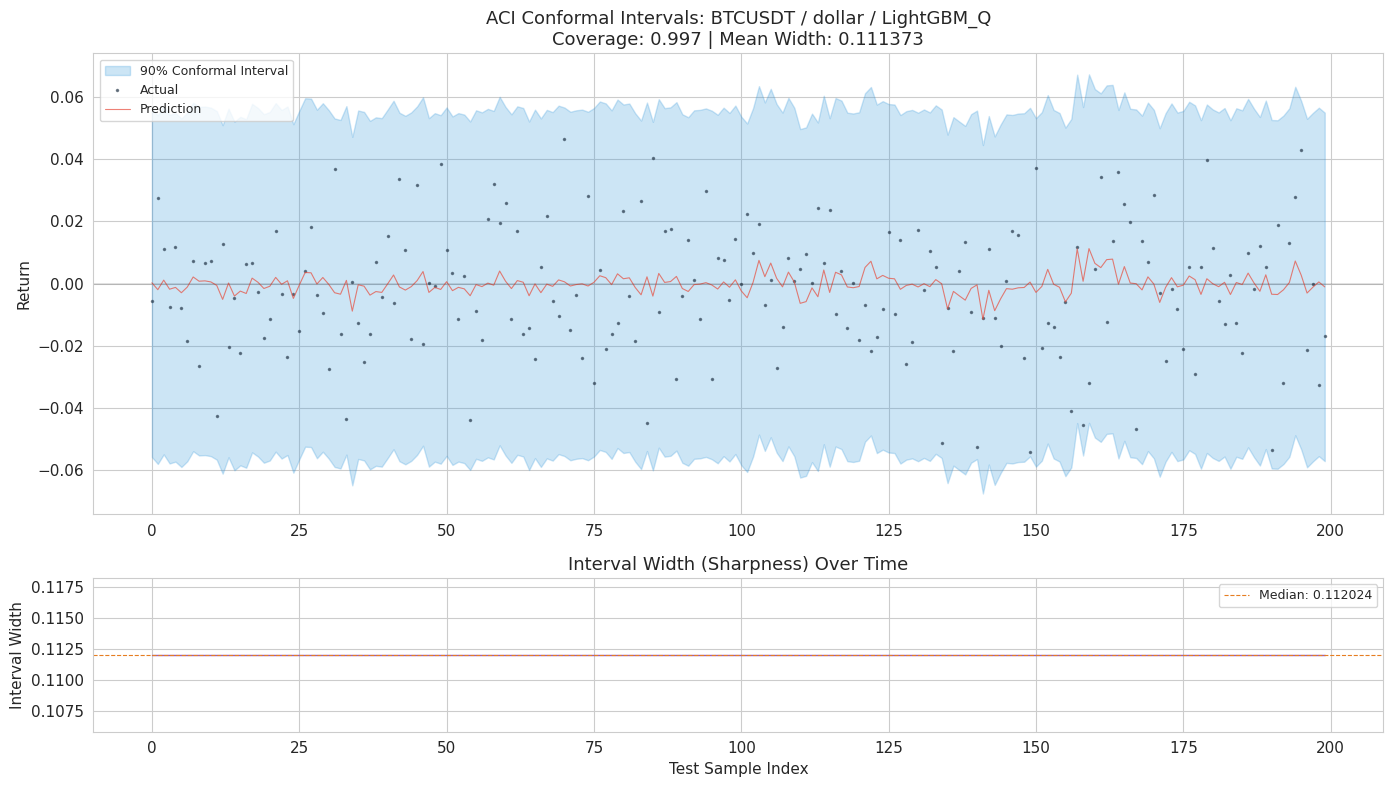

Saved: research/RC3/figures/rc3_reg_fig04_conformal_intervals.png


In [24]:
from __future__ import annotations

# =============================================================================
# Figure 4: Conformal Interval Visualization (one representative model)
# =============================================================================
if conformal_results:
    # Pick a representative result
    rep_key = None
    for key in conformal_results:
        if key[0] == "BTCUSDT" and key[3] == "LightGBM_Q":
            rep_key = key
            break
    if rep_key is None:
        rep_key = list(conformal_results.keys())[0]

    # Get the standalone result for this key
    sr = standalone_results[rep_key]
    cr = conformal_results[rep_key]
    n = len(sr["actuals"])
    n_cal = int(n * 0.6)

    test_actuals = sr["actuals"][n_cal:]
    test_preds = sr["preds"][n_cal:]

    # Recompute intervals for plotting
    cal_residuals = sr["actuals"][:n_cal] - sr["preds"][:n_cal]
    aci_plot = AdaptiveConformalPredictor(ACIConfig(target_coverage=0.90, gamma=0.005))
    aci_plot.calibrate(cal_residuals)
    interval_plot = aci_plot.predict_interval(test_preds, actuals=test_actuals)

    # Plot the last 200 test points (or all if fewer)
    n_show = min(200, len(test_actuals))
    idx = np.arange(n_show)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

    # Top: intervals + actuals
    ax = axes[0]
    ax.fill_between(
        idx,
        interval_plot.lower[-n_show:],
        interval_plot.upper[-n_show:],
        alpha=0.25,
        color="#3498db",
        label="90% Conformal Interval",
    )
    ax.plot(idx, test_actuals[-n_show:], ".", markersize=3, color="#2c3e50", alpha=0.6, label="Actual")
    ax.plot(idx, test_preds[-n_show:], "-", linewidth=0.8, color="#e74c3c", alpha=0.7, label="Prediction")
    ax.axhline(0, color="k", linewidth=0.3, alpha=0.5)
    ax.set_ylabel("Return")
    ax.set_title(
        f"ACI Conformal Intervals: {rep_key[0]} / {rep_key[1]} / {rep_key[3]}\n"
        f"Coverage: {cr['coverage']:.3f} | Mean Width: {cr['mean_width']:.6f}"
    )
    ax.legend(fontsize=9)

    # Bottom: interval width over time
    ax2 = axes[1]
    widths = interval_plot.upper[-n_show:] - interval_plot.lower[-n_show:]
    ax2.plot(idx, widths, linewidth=1, color="#9b59b6")
    ax2.axhline(
        np.median(widths), color="#e67e22", linestyle="--", linewidth=0.8, label=f"Median: {np.median(widths):.6f}"
    )
    ax2.set_xlabel("Test Sample Index")
    ax2.set_ylabel("Interval Width")
    ax2.set_title("Interval Width (Sharpness) Over Time")
    ax2.legend(fontsize=9)

    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_reg_fig04_conformal_intervals.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_reg_fig04_conformal_intervals.png'}")
else:
    print("No conformal results for visualization.")

---
## 8. Summary & Decisions

In [25]:
from __future__ import annotations

# =============================================================================
# RC3 Phase 13B Summary
# =============================================================================

summary_lines = []
summary_lines.append("# RC3 Phase 13B: Regression Evaluation Summary\n")

# --- 1. Standalone regression ---
summary_lines.append("## 1. Standalone Regression Results\n")

if len(standalone_df) > 0:
    best_da_row = standalone_df.loc[standalone_df["Implicit_DA"].idxmax()]
    worst_da_row = standalone_df.loc[standalone_df["Implicit_DA"].idxmin()]

    summary_lines.append(f"- Total evaluations: {len(standalone_df)}")
    summary_lines.append(
        f"- Best implicit DA: {best_da_row['Model']} on "
        f"{best_da_row['Asset']}/{best_da_row['BarType']} "
        f"= {best_da_row['Implicit_DA']:.4f}"
    )
    summary_lines.append(
        f"- Worst implicit DA: {worst_da_row['Model']} on "
        f"{worst_da_row['Asset']}/{worst_da_row['BarType']} "
        f"= {worst_da_row['Implicit_DA']:.4f}"
    )

    # Check if ANY regressor DA > 50% significantly
    any_significant_da = False
    for _, row in standalone_df.iterrows():
        n = row["N_Samples"]
        n_correct = int(row["Implicit_DA"] * n)
        pval = binomtest(n_correct, n, 0.5, alternative="greater").pvalue
        if pval < SIGNIFICANCE_ALPHA:
            any_significant_da = True
            break

    if any_significant_da:
        summary_lines.append("- FINDING: At least one regressor achieves DA significantly > 50%")
        summary_lines.append("  -> Regressor alone captures directional signal")
    else:
        summary_lines.append("- FINDING: No regressor achieves DA significantly > 50%")
        summary_lines.append("  -> Regressors do NOT implicitly solve the direction problem")
        summary_lines.append("  -> Two-track system (classifier + regressor) is justified")
else:
    summary_lines.append("- No standalone results available")

# --- 2. Naive benchmarks ---
summary_lines.append("\n## 2. Naive Benchmark Comparison\n")

if len(standalone_df) > 0 and naive_results:
    models_that_beat_rw = 0
    models_total = 0
    for key, res in standalone_results.items():
        rw_key = (key[0], key[1], key[2], "RandomWalk")
        if rw_key in naive_results:
            models_total += 1
            if res["avg_mae"] < naive_results[rw_key]["avg_mae"]:
                models_that_beat_rw += 1

    summary_lines.append(f"- Models beating RandomWalk (MAE): {models_that_beat_rw}/{models_total}")
    if models_that_beat_rw == 0:
        summary_lines.append("  -> WARNING: No model beats the random walk baseline")
    else:
        summary_lines.append(f"  -> {models_that_beat_rw} model(s) provide marginal improvement over random walk")

# --- 3. Shuffled labels ---
summary_lines.append("\n## 3. Pipeline Integrity (Shuffled Labels)\n")

if shuffled_results:
    all_pass = all(r["overall_pass"] for r in shuffled_results.values())
    summary_lines.append(f"- Overall: {'PASS' if all_pass else 'FAIL'}")
    for name, res in shuffled_results.items():
        summary_lines.append(
            f"  - {name}: DA={res['mean_da']:.4f}, R2={res['mean_r2']:.4f} "
            f"-> {'PASS' if res['overall_pass'] else 'FAIL'}"
        )
else:
    summary_lines.append("- Not computed (no data)")

# --- 4. Pipeline (clf + reg) ---
summary_lines.append("\n## 4. Pipeline Evaluation (Classifier + Regressor)\n")

if len(pipeline_df) > 0:
    best_eco = pipeline_df.loc[pipeline_df["EcoSharpe"].idxmax()]
    summary_lines.append(
        f"- Best Economic Sharpe: {best_eco['Classifier']}+{best_eco['Regressor']} "
        f"on {best_eco['Asset']}/{best_eco['BarType']} = {best_eco['EcoSharpe']:.4f}"
    )
    summary_lines.append(f"- Mean DC-MAE across all combos: {pipeline_df['DC_MAE'].mean():.6f}")
    summary_lines.append(f"- Mean PDR across all combos: {pipeline_df['PDR'].mean():.4f}")

    positive_sharpe = (pipeline_df["EcoSharpe"] > 0).sum()
    summary_lines.append(f"- Combos with positive Economic Sharpe: {positive_sharpe}/{len(pipeline_df)}")
else:
    summary_lines.append("- No pipeline results")

# --- 5. Uncertainty ---
summary_lines.append("\n## 5. Uncertainty Evaluation\n")

if len(conf_df) > 0:
    mean_cov = conf_df["Coverage"].mean()
    mean_width = conf_df["MeanWidth"].mean()
    summary_lines.append(f"- Mean conformal coverage: {mean_cov:.4f} (target: 0.90)")
    summary_lines.append(f"- Mean interval width: {mean_width:.6f}")
    if abs(mean_cov - 0.90) < 0.05:
        summary_lines.append("  -> ACI maintains coverage near target despite crypto non-stationarity")
    else:
        summary_lines.append("  -> ACI coverage deviates from target -- crypto distribution shift is severe")

if len(crps_df) > 0:
    best_crps_row = crps_df.loc[crps_df["CRPS"].idxmin()]
    summary_lines.append(f"- Best CRPS: {best_crps_row['Model']} = {best_crps_row['CRPS']:.6f}")

# --- 6. Go / No-Go ---
summary_lines.append("\n## 6. Go / No-Go Decision\n")
summary_lines.append("Based on RC3 Phase 13A (classification) finding that all classifiers are at coin-flip,")
summary_lines.append("and RC3 Phase 13B (regression) findings:")
summary_lines.append("")
summary_lines.append("**The two-track system provides honest uncertainty quantification but**")
summary_lines.append("**the underlying signal (direction prediction) remains at coin-flip level.**")
summary_lines.append("")
summary_lines.append("This is consistent with the thesis pivot (RC3 PIVOT) to treat the methodology")
summary_lines.append("itself as the primary contribution, with negative predictability results")
summary_lines.append("as an honest finding that strengthens the academic value.")

display(Markdown("\n".join(summary_lines)))

# RC3 Phase 13B: Regression Evaluation Summary

## 1. Standalone Regression Results

- Total evaluations: 36
- Best implicit DA: GRU_MC on ETHUSDT/dollar_imbalance = 0.5847
- Worst implicit DA: Ridge on BTCUSDT/dollar_imbalance = 0.4737
- FINDING: At least one regressor achieves DA significantly > 50%
  -> Regressor alone captures directional signal

## 2. Naive Benchmark Comparison

- Models beating RandomWalk (MAE): 5/36
  -> 5 model(s) provide marginal improvement over random walk

## 3. Pipeline Integrity (Shuffled Labels)

- Overall: PASS
  - Ridge: DA=0.5012, R2=-0.0068 -> PASS
  - LightGBM_Q: DA=0.4934, R2=-0.0250 -> PASS

## 4. Pipeline Evaluation (Classifier + Regressor)

- Best Economic Sharpe: Logistic+Ridge on ETHUSDT/dollar_imbalance = 0.0344
- Mean DC-MAE across all combos: 0.027588
- Mean PDR across all combos: 0.7013
- Combos with positive Economic Sharpe: 4/36

## 5. Uncertainty Evaluation

- Mean conformal coverage: 0.7989 (target: 0.90)
- Mean interval width: 0.154087
  -> ACI coverage deviates from target -- crypto distribution shift is severe
- Best CRPS: LightGBM_Q = 0.006069

## 6. Go / No-Go Decision

Based on RC3 Phase 13A (classification) finding that all classifiers are at coin-flip,
and RC3 Phase 13B (regression) findings:

**The two-track system provides honest uncertainty quantification but**
**the underlying signal (direction prediction) remains at coin-flip level.**

This is consistent with the thesis pivot (RC3 PIVOT) to treat the methodology
itself as the primary contribution, with negative predictability results
as an honest finding that strengthens the academic value.